In [3]:
import yfinance as yf
import pandas as pd

In [5]:

tickers = [
    'AAPL',
    'MSFT',
    'GOOGL',
    'AMZN',
    'TSLA',
    'META',
    'NVDA'
]

all_data = []

for ticker in tickers:

    df = yf.download(
        ticker,
        start="2011-03-01",
        end="2020-06-11",
        progress=False
    )

    # Flatten multi-index columns immediately
    df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]

    # Reset index so Date becomes a column
    df.reset_index(inplace=True)

    # Add ticker column
    df['stock'] = ticker

    # Keep only needed columns
    df = df[
        ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'stock']
    ]

    all_data.append(df)

    print(f"Downloaded {ticker}")

Downloaded AAPL
Downloaded MSFT
Downloaded GOOGL
Downloaded AMZN
Downloaded TSLA
Downloaded META
Downloaded NVDA


In [6]:
stock_df = pd.concat(all_data, ignore_index=True)

In [7]:
print(stock_df.columns)

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'stock'], dtype='str')


In [8]:
stock_df.head()

,Date,Open,High,Low,Close,Volume,stock
0,2011-03-01,10.641145,10.648628,10.407948,10.456742,456136800,AAPL
1,2011-03-02,10.476202,10.607618,10.429502,10.540862,602590800,AAPL
2,2011-03-03,10.692635,10.770466,10.654616,10.763581,500788400,AAPL
3,2011-03-04,10.778845,10.785431,10.709395,10.776750,453266800,AAPL
4,2011-03-07,10.818667,10.826750,10.516619,10.637857,546123200,AAPL


Normalize Dates

In [9]:
news_df = pd.read_csv("../data/newsData/raw_analyst_ratings.csv")

In [10]:
news_df['date'] = pd.to_datetime(
    news_df['date'],
    format='mixed',
    utc=True,
    errors='coerce'
)

news_df['date'] = news_df['date'].dt.tz_localize(None)

In [11]:
news_df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 14:30:54,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 14:45:20,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 08:30:07,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 16:45:06,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 15:38:59,A


In [12]:
news_df['trading_date'] = news_df['date'].dt.date

news_df.head()

,Unnamed: 0,headline,url,publisher,date,stock,trading_date
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 14:30:54,A,2020-06-05
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 14:45:20,A,2020-06-03
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 08:30:07,A,2020-05-26
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 16:45:06,A,2020-05-22
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 15:38:59,A,2020-05-22


In [12]:
stock_df['Date'] = pd.to_datetime(stock_df['Date'])

stock_df['Date'] = stock_df['Date'].dt.date

Handle Weekends & Holidays

News published Saturday
→ Market closed
→ Move to Monday trading day

In [13]:
trading_days = sorted(stock_df['Date'].unique())

In [14]:
def align_to_next_trading_day(news_date):
    for trading_day in trading_days:
        if trading_day >= news_date:
            return trading_day
    return None


news_df['trading_date'] = news_df['trading_date'].apply(
    align_to_next_trading_day
)

Sentiment Analysis

In [13]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [14]:
analyzer = SentimentIntensityAnalyzer()

#Compute sentiment:

news_df['sentiment_score'] = news_df['headline'].apply(
    lambda x: analyzer.polarity_scores(str(x))['compound']
)

In [15]:
news_df['trading_date'] = pd.to_datetime(news_df['trading_date']).dt.date
stock_df['Date'] = pd.to_datetime(stock_df['Date']).dt.date

Aggregate Daily Sentiment Per Stock

In [19]:
#multiple articles appear the same day:

daily_sentiment = news_df.groupby(
    ['stock', 'trading_date']
)['sentiment_score'].mean().reset_index()

In [20]:
#Calculate Daily Stock Returns

stock_df = stock_df.sort_values(['stock', 'Date'])

stock_df['daily_return'] = stock_df.groupby('stock')[
    'Close'
].pct_change() * 100

stock_df[['Date', 'stock', 'Close', 'daily_return']].head()

,Date,stock,Close,daily_return
0,2011-03-01,AAPL,10.456742,NaN
1,2011-03-02,AAPL,10.540862,0.804455
2,2011-03-03,AAPL,10.763581,2.112912
3,2011-03-04,AAPL,10.776750,0.122342
4,2011-03-07,AAPL,10.637857,-1.288813


In [21]:
news_df['trading_date'] = pd.to_datetime(news_df['trading_date'])
stock_df['Date'] = pd.to_datetime(stock_df['Date'])

In [22]:
stock_dates = stock_df[['stock', 'Date']].drop_duplicates()

In [23]:
news_df = news_df.sort_values(['stock', 'trading_date'])
stock_dates = stock_dates.sort_values(['stock', 'Date'])

In [24]:
merged_df = pd.merge_asof(
    news_df.sort_values('trading_date'),
    stock_df.sort_values('Date'),
    left_on='trading_date',
    right_on='Date',
    by='stock',
    direction='forward'
)

In [25]:
merged_df = merged_df.dropna(subset=['daily_return', 'sentiment_score'])

In [26]:
from scipy.stats import pearsonr

correlation, p_value = pearsonr(
    merged_df['sentiment_score'],
    merged_df['daily_return']
)

print(correlation, p_value)

0.09206455254419704 2.982234351194602e-15


In [27]:
print(merged_df.shape)
print(merged_df.head())

(7319, 15)
        Unnamed: 0                                           headline  \
116360      932188                        Nvidia Goes Negative (NVDA)   
117133      932187  Auriga Still Not Sure Where Reality Lies For N...   
117135      932186  Goldman Sachs Gives Color On Semiconductors (N...   
117535      932182  JPM Says "Our Bearish View on the Company's Ex...   
117539      932185       JP Morgan Upgrades NVIDIA To Neutral, $21 PT   

                                                      url       publisher  \
116360  https://www.benzinga.com/market-update/11/03/9...     Scott Rubin   
117133  https://www.benzinga.com/analyst-ratings/analy...  BenzingaStaffB   
117135  https://www.benzinga.com/analyst-ratings/analy...  Benzinga Staff   
117535  https://www.benzinga.com/analyst-ratings/analy...  Benzinga Staff   
117539  https://www.benzinga.com/analyst-ratings/upgra...       Joe Young   

             date stock trading_date  sentiment_score       Date      Open  \
116360 20

Aggregate sentiment per stock-day

visualizations

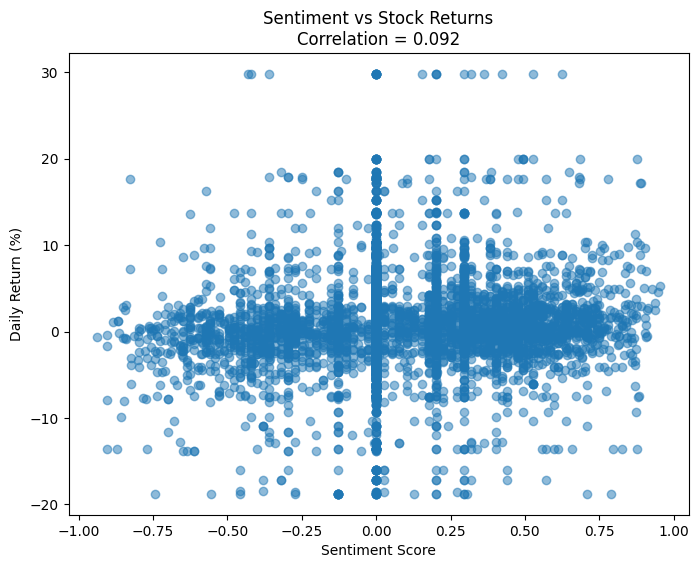

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    merged_df['sentiment_score'],
    merged_df['daily_return'],
    alpha=0.5
)

plt.xlabel('Sentiment Score')
plt.ylabel('Daily Return (%)')
plt.title(f'Sentiment vs Stock Returns\nCorrelation = {correlation:.3f}')

plt.show()

In [29]:
import numpy as np

merged_df['sentiment_category'] = np.where(
    merged_df['sentiment_score'] > 0.05,
    'Positive',
    np.where(
        merged_df['sentiment_score'] < -0.05,
        'Negative',
        'Neutral'
    )
)

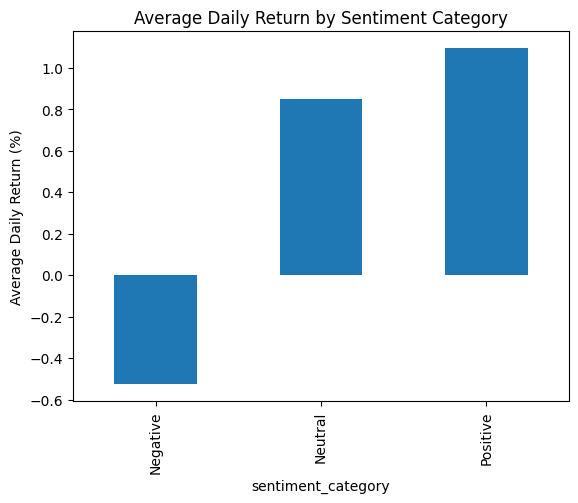

In [30]:
category_returns = merged_df.groupby(
    'sentiment_category'
)['daily_return'].mean()

category_returns.plot(kind='bar')

plt.title('Average Daily Return by Sentiment Category')
plt.ylabel('Average Daily Return (%)')

plt.show()